# Evaluierung der Modell-Interpretierbarkeit: Baseline vs. Global Average Pooling

**Autor:** Nikolai Steffan
**Bezug:** Kapitel 7.3 der Studienarbeit
**Ziel:** Dieses Notebook dient der quantitativen und qualitativen Analyse der Interpretierbarkeit (Faithfulness) von Transformer-basierten IDS-Modellen.

---

## 1. Einleitung und Zielsetzung

In diesem Notebook wird untersucht, wie sich architektonische Entscheidungen auf die Erklärbarkeit des Modells auswirken. Gemäß den theoretischen Grundlagen der Arbeit (Kapitel 7.3) wird die Hypothese geprüft, dass die Verwendung von **Global Average Pooling (GAP)** anstelle des klassischen **[CLS]-Token Poolings** zu robusteren und treueren (faithful) Erklärungen führt.

Die Analyse erfolgt in drei Schritten:
1.  **Qualitative Analyse:** Visualisierung der Attention-Gewichte (Heatmaps) für spezifische Angriffsvektoren.
2.  **Quantitative Methodik:** Implementierung des **Accuracy Delta** als Metrik für die *Faithfulness* einer Erklärungsmethode.
3.  **Vergleichende Evaluation:** Gegenüberstellung der Baseline-Architektur und der GAP-Architektur unter Verwendung von *Attention* und *SHAP*.

---

## 2. Setup: Importieren der Bibliotheken und Konfiguration

Zunächst werden die notwendigen PyTorch- und HuggingFace-Bibliotheken sowie die Analyse-Tools (SHAP) geladen. Es wird sichergestellt, dass die Umgebungsvariablen für die GPU-Nutzung korrekt gesetzt sind.

## Environment vorbereiten

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    DataCollatorWithPadding
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import logging
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

# Logging Setup
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-28 08:46:54.146019: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU Memory: 23.6 GB


## Setze die notwendigen Pfade

In [4]:
# Konfiguration - Passe diese Werte an deine Bedürfnisse an
CONFIG = {
    'MODEL_NAME': "huawei-noah/TinyBERT_General_4L_312D",  # TinyBERT Model
    'Train_DATA_CSV_PATH': "Project/bert_train_sequences_v4.csv",                   # Pfad zu deinen Trainingsdaten
    'Train_LABELS_CSV_PATH': "Project/y_train_resampled_attackCategoryEncoded.csv",               # Pfad zu deinen Labels
    'Eval_LABELS_CSV_PATH': "Project/y_test_Attack_Category_Encoded.csv",               # Pfad zu deinen Labels
    'Eval_DATA_CSV_PATH': "Project/bert_test_sequences_v4_no_sep.csv",                   # Pfad zu deinen Trainingsdaten
    'LABEL_COLUMN_TRAIN': 'attackCategoryEncoded',
    'LABEL_COLUMN_TEST': 'Attack_Category_Encoded',            # Spalte mit den encodeten Labels
    'BATCH_SIZE': 16,                                       # Reduzieren falls Speicher-Probleme

   # 'OUTPUT_DIR': "./tinybert_finetuned_v7_no_sep",
}


print("Konfiguration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Konfiguration:
  MODEL_NAME: huawei-noah/TinyBERT_General_4L_312D
  Train_DATA_CSV_PATH: Project/bert_train_sequences_v4.csv
  Train_LABELS_CSV_PATH: Project/y_train_resampled_attackCategoryEncoded.csv
  Eval_LABELS_CSV_PATH: Project/y_test_Attack_Category_Encoded.csv
  Eval_DATA_CSV_PATH: Project/bert_test_sequences_v4_no_sep.csv
  LABEL_COLUMN_TRAIN: attackCategoryEncoded
  LABEL_COLUMN_TEST: Attack_Category_Encoded
  BATCH_SIZE: 16


---

## 3. Datenbasis und Modell-Laden

### 3.1. Laden der Testdaten
Für die Evaluation wird der **NF-UNSW-NB15-v3** Testdatensatz verwendet. Die Daten wurden in der Pre-Modeling-Phase bereits in BERT-kompatible Sequenzen konvertiert.

In [5]:
def load_and_prepare_data(data_csv_path, labels_csv_path, label_column):
    """
    Lädt und bereitet die Daten vor
    
    Args:
        data_csv_path: Pfad zur CSV mit den Trainingsdaten
        labels_csv_path: Pfad zur CSV mit den Labels
        label_column: Name der Spalte mit den encodeten Labels
    
    Returns:
        texts, labels: Vorbereitete Texte und Labels
    """
    logger.info("Lade Daten...")
    
    # Daten laden
    data_df = pd.read_csv(data_csv_path, sep='\t', encoding='utf-8')
    labels_df = pd.read_csv(labels_csv_path, sep='\t', encoding='utf-8')
    
    logger.info(f"Daten shape: {data_df.shape}")
    logger.info(f"Labels shape: {labels_df.shape}")
    logger.info(f"Labels shape: {labels_df.columns}")
    
    # Überprüfe ob die Anzahl der Zeilen übereinstimmt
    if len(data_df) != len(labels_df):
        raise ValueError(f"Anzahl der Datenzeilen ({len(data_df)}) stimmt nicht mit Anzahl der Labels ({len(labels_df)}) überein!")
    
    # Annahme: die erste Spalte in data_df enthält die formatierten Texte
    texts = data_df.iloc[:, 0].tolist()
    
    # Labels aus der spezifizierten Spalte laden (bereits encoded)
    if label_column not in labels_df.columns:
        raise ValueError(f"Label Spalte '{label_column}' nicht in den Label-Daten gefunden!")
    
    labels = labels_df[label_column].values
    
    logger.info(f"Anzahl unique Labels: {len(np.unique(labels))}")
    logger.info(f"Label Bereich: {np.min(labels)} - {np.max(labels)}")
    
    return texts, labels

# Daten laden
"""train_texts, train_labels = load_and_prepare_data(
    CONFIG['Train_DATA_CSV_PATH'], 
    CONFIG['Train_LABELS_CSV_PATH'], 
    CONFIG['LABEL_COLUMN_TRAIN']
)"""
val_texts, val_labels = load_and_prepare_data(
    CONFIG['Eval_DATA_CSV_PATH'], 
    CONFIG['Eval_LABELS_CSV_PATH'], 
    CONFIG['LABEL_COLUMN_TEST']
)


INFO:__main__:Lade Daten...
INFO:__main__:Daten shape: (473085, 1)
INFO:__main__:Labels shape: (473085, 3)
INFO:__main__:Labels shape: Index(['Attack', 'Label', 'Attack_Category_Encoded'], dtype='object')
INFO:__main__:Anzahl unique Labels: 10
INFO:__main__:Label Bereich: 0 - 9


In [6]:
from Project.tinybert_with_gap import TinyBertWithGAP

### 3.2. Initialisierung der Vergleichsmodelle

Es werden zwei Varianten des TinyBERT-Modells geladen, um den architektonischen Einfluss zu isolieren:

1.  **Baseline-Modell:** Standard TinyBERT-Architektur, die das [CLS]-Token für die Klassifikation nutzt.
2.  **GAP-Modell:** Modifizierte Architektur, bei der die Repräsentation über alle Tokens der letzten Schicht gemittelt wird (Global Average Pooling).

Beide Modelle wurden zuvor auf dem gleichen Trainingsdatensatz fine-getunt.

In [ ]:
from safetensors.torch import load_file
# Pfad zum gespeicherten Modell (aus der Konfiguration)
# Stellen Sie sicher, dass die Zelle mit der CONFIG-Variable vorher ausgeführt wurde.
model_path = "Project/models/tinybert_finetuned_v7_no_sep"
model_GAP_path = "Project/models/tinybert_finetuned_v7_GAP_no_sep"

print(f"Lade das fein-getunte Modell aus: {model_path}")

# Lade den Tokenizer und das Modell
try:
    # Diese Klassen müssen bereits importiert sein (sind sie weiter oben im Notebook)    
    tokenizer_loaded = AutoTokenizer.from_pretrained(model_path)
    model_loaded = AutoModelForSequenceClassification.from_pretrained(model_path, output_attentions=True)
    print("Erstes Modell und Tokenizer erfolgreich für die Analyse geladen.")

    tokenizer_GAP_loaded = AutoTokenizer.from_pretrained(model_GAP_path)
    model_GAP_loaded = TinyBertWithGAP(
        CONFIG['MODEL_NAME'], 
        num_labels=10,
        output_attentions=True)
    print("Model Loaded")
    weights_path = os.path.join(model_GAP_path, "model.safetensors")
    state_dict = load_file(weights_path) 

    model_GAP_loaded.load_state_dict(state_dict)
    model_GAP_loaded.eval()
    # 'device' muss ebenfalls aus einer vorherigen Zelle definiert sein
    model_loaded.to(device) 
    model_GAP_loaded.to(device) 
    # Wichtig: Das Modell in den Evaluationsmodus schalten
    model_loaded.eval()
    
    print("Modell und Tokenizer erfolgreich für die Analyse geladen.")

except Exception as e:
    print(f"Fehler beim Laden des Modells: {e}")


Lade das fein-getunte Modell aus: Project/models/tinybert_finetuned_v7_no_sep
Erstes Modell und Tokenizer erfolgreich für die Analyse geladen.
Model Loaded
Modell und Tokenizer erfolgreich für die Analyse geladen.


---

## 4. Qualitative Analyse: Attention-Visualisierung

In diesem Abschnitt wird die intrinsische Interpretierbarkeit der Modelle untersucht. Durch die Extraktion der Attention-Gewichte aus der letzten Encoder-Schicht visualisieren wir, worauf das Modell seinen Fokus legt.

**Ziel:** Plausibilitätsprüfung der Modellentscheidungen anhand eines **DoS-Angriffs** (Label 3). Es wird erwartet, dass relevante Merkmale (z.B. `dstToSrcAvgThroughput` oder `inPkts`) eine höhere Aufmerksamkeit erhalten.

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Analysiere Sample #763 mit Label: DoS (3)
Input Text: [CLS] dstToSrcAvgThroughput: 0.48 dstToSrcIatAvg: 0.47 dstToSrcSecondBytes: 0.05 inBytes: 0.36 inPkts: 0.23 longestFlowPkt: 0.53 minIpPktLen: 0.57 numPkts128To256Bytes: 0.00 outBytes: 0.35 retransmittedInBytes: 0.29 shortestFlowPkt: 0.35 srcToDstSecondBytes: 0.04 l7Proto: 13 dnsQueryType: 0 icmpIpv4Type: 28 [SEP]


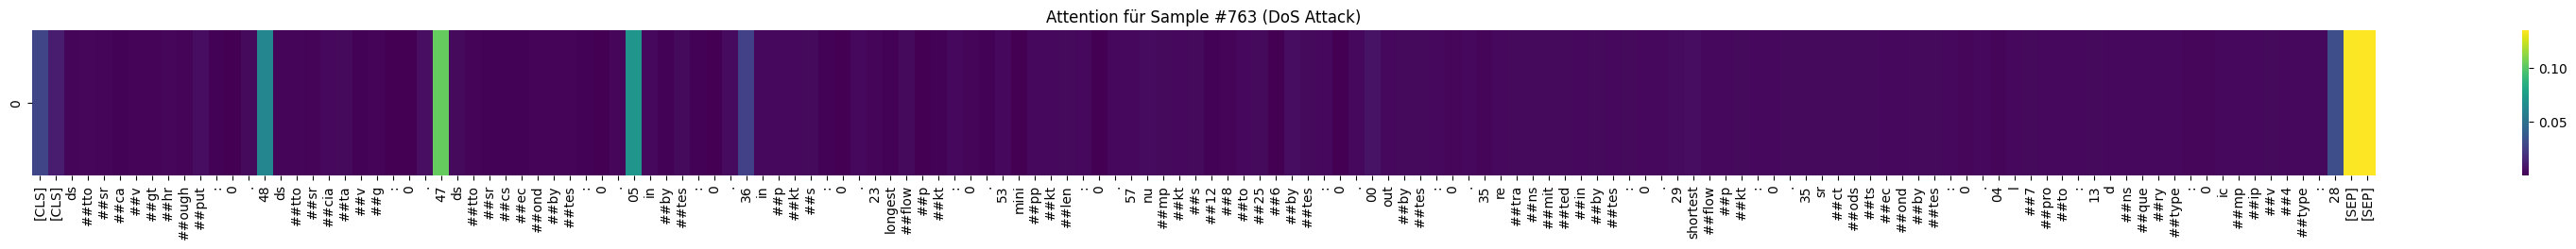

Fehler beim Extrahieren der Attention-Gewichte: 'dict' object has no attribute 'attentions'
Es scheint wohl ein eigenes Modell zu ein


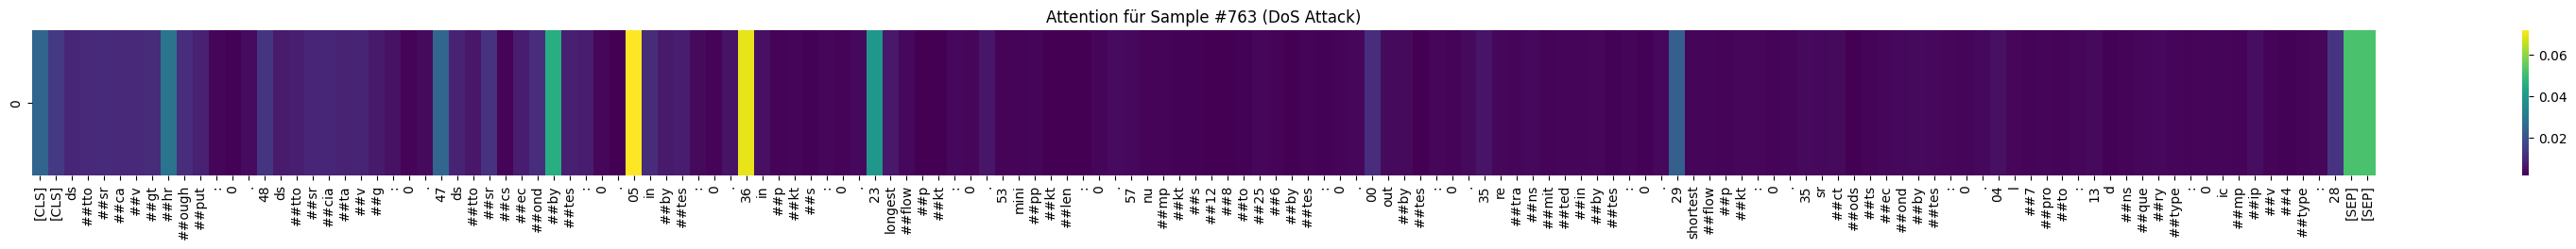

In [8]:
def get_attention_for_text(text, model, tokenizer):
    """Gibt die Attention-Gewichte für einen einzelnen Text zurück."""
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Attention-Gewichte extrahieren (von allen Layern und Köpfen)
    try:
        attentions = outputs.attentions
    except Exception as e:
        print(f"Fehler beim Extrahieren der Attention-Gewichte: {e}")
        print("Es scheint wohl ein eigenes Modell zu ein")
        attentions = outputs['attentions']
    # Wir nehmen den Durchschnitt über alle Köpfe und Layer
    # attentions ist ein Tupel von Tensoren (einer pro Layer)
    # Jeder Tensor hat die Form [batch_size, num_heads, seq_length, seq_length]
    attention_tensor = torch.cat(attentions, dim=0) # Layer zusammenfügen
    attention_tensor = torch.mean(attention_tensor, dim=1) # Köpfe mitteln
    attention_tensor = torch.mean(attention_tensor, dim=0) # Layer mitteln
    
    # Token-zu-Token-Attention für das [CLS]-Token (das für die Klassifikation verwendet wird)
    cls_attention = attention_tensor[0, :].cpu().numpy()
    
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    return tokens, cls_attention

def plot_attention_heatmap(tokens, attention_scores, title='Attention Heatmap'):
    """Visualisiert die Attention Scores als Heatmap."""
    plt.figure(figsize=(40, 2))
    sns.heatmap([attention_scores], xticklabels=tokens, cmap='viridis', cbar=True)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

# Beispiel: Attention für einen Angriffs-Flow visualisieren
# Suchen wir einen bekannten Angriffs-Sample (z.B. DoS)
attack_category_map = {0: 'Analysis', 1: 'Backdoor', 2: 'Benign', 3: 'DoS', 4: 'Exploits', 5: 'Fuzzers', 6: 'Generic', 7: 'Reconnaissance', 8: 'Shellcode', 9: 'Worms'}
dos_label = 3
sample_idx = np.where(np.array(val_labels) == dos_label)[0][0] # Finde den ersten DoS-Angriff
sample_text = val_texts[sample_idx]
sample_label = val_labels[sample_idx]

print(f"Analysiere Sample #{sample_idx} mit Label: {attack_category_map[sample_label]} ({sample_label})")
print(f"Input Text: {sample_text}")

tokens, attention_scores = get_attention_for_text(sample_text, model_loaded, tokenizer_loaded)
plot_attention_heatmap(tokens, attention_scores, title=f'Attention für Sample #{sample_idx} (DoS Attack)')

tokens, attention_scores = get_attention_for_text(sample_text, model_GAP_loaded, tokenizer_loaded)
plot_attention_heatmap(tokens, attention_scores, title=f'Attention für Sample #{sample_idx} (DoS Attack)')

---

## 5. Quantitative Analyse: Perturbationstests

### 5.1. Methodik: Accuracy Delta

Um die Qualität der Erklärungen objektiv zu messen, implementieren wir einen Perturbationstest zur Bestimmung der **Faithfulness**.

Das Verfahren folgt dem Schema:
1.  **Identifikation:** Eine XAI-Methode (Attention oder SHAP) identifiziert die $k$ wichtigsten Tokens.
2.  **Perturbation:** Diese Tokens werden maskiert (aus der Eingabe entfernt).
3.  **Messung:** Die Klassifikationsgenauigkeit wird auf den maskierten Daten erneut berechnet.

Die zentrale Metrik ist das **Accuracy Delta**:
$$\Delta_{Acc} = Acc_{original} - Acc_{masked}$$

Ein **hohes Accuracy Delta** ist wünschenswert, da es belegt, dass die entfernten Merkmale tatsächlich essenziell für die Entscheidung des Modells waren.

In [9]:
def evaluate_model(texts, labels, model, tokenizer, batch_size):
    """Evaluiert das Modell auf einem gegebenen Datensatz und gibt die Genauigkeit zurück."""
    model.eval()
    all_preds = []
    dataset = torch.utils.data.TensorDataset(torch.arange(len(texts)))
    loader = DataLoader(dataset, batch_size=batch_size)
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            batch_indices = batch[0].tolist()
            batch_texts = [texts[i] for i in batch_indices]
            
            inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True).to(device)
            outputs = model(**inputs)
            try:
                preds = torch.argmax(outputs.logits, dim=1)
            except Exception as e:
                preds = torch.argmax(outputs['logits'], dim=1)
            all_preds.extend(preds.cpu().numpy())
            
    return accuracy_score(labels, all_preds)

def create_masked_dataset(texts, labels, model, tokenizer, batch_size, percentile=90):
    """Maskiert die wichtigsten Tokens basierend auf Attention."""
    masked_texts = []
    mask_token_id = tokenizer.mask_token_id
    
    dataset = torch.utils.data.TensorDataset(torch.arange(len(texts)))
    loader = DataLoader(dataset, batch_size=batch_size)

    for batch in tqdm(loader, desc="Masking Dataset"):
        batch_indices = batch[0].tolist()
        batch_texts = [texts[i] for i in batch_indices]
        
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
        try:
            attentions = torch.stack(outputs.attentions).mean(dim=0).mean(dim=1)
        except Exception as e:
            attentions = torch.stack(outputs['attentions']).mean(dim=0).mean(dim=1)
        cls_attentions = attentions[:, 0, :].cpu() # Attention vom [CLS] token zu allen anderen
        
        for i in range(len(batch_texts)):
            input_ids = inputs['input_ids'][i].cpu().tolist()
            attention_scores = cls_attentions[i, :len(input_ids)].numpy()
            
            # Finde den Schwellenwert für die wichtigsten Tokens
            threshold = np.percentile(attention_scores, percentile)
            
            # Maskiere die Tokens mit hoher Attention (außer [CLS] und [SEP])
            masked_input_ids = []
            for token_id, score in zip(input_ids, attention_scores):
                if score >= threshold and token_id not in [tokenizer.cls_token_id, tokenizer.sep_token_id]:
                    masked_input_ids.append(mask_token_id)
                else:
                    masked_input_ids.append(token_id)
            
            masked_texts.append(tokenizer.decode(masked_input_ids, skip_special_tokens=True))
            
    return masked_texts

"""# 1. Original-Genauigkeit berechnen
print("Berechne Original-Genauigkeit (Accuracy(D))...")
original_accuracy = evaluate_model(val_texts, val_labels, model_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])
print(f"Original Accuracy: {original_accuracy:.4f}")

# 2. Maskiertes Dataset erstellen
print("\nErstelle maskiertes Dataset (D_M)...")
masked_val_texts = create_masked_dataset(val_texts, val_labels, model_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])

# 3. Maskierte Genauigkeit berechnen
print("\nBerechne maskierte Genauigkeit (Accuracy(D_M))...")
masked_accuracy = evaluate_model(masked_val_texts, val_labels, model_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])
print(f"Masked Accuracy: {masked_accuracy:.4f}")

# 4. Accuracy Delta berechnen
accuracy_delta = original_accuracy - masked_accuracy
print("\n===================================")
print(f"🎯 Accuracy Delta: {accuracy_delta:.4f}")
print("===================================")
print("Ein hoher Wert bedeutet, dass das Modell seine Entscheidungen auf die Features stützt, die es als wichtig erachtet.")"""

'# 1. Original-Genauigkeit berechnen\nprint("Berechne Original-Genauigkeit (Accuracy(D))...")\noriginal_accuracy = evaluate_model(val_texts, val_labels, model_loaded, tokenizer_loaded, CONFIG[\'BATCH_SIZE\'])\nprint(f"Original Accuracy: {original_accuracy:.4f}")\n\n# 2. Maskiertes Dataset erstellen\nprint("\nErstelle maskiertes Dataset (D_M)...")\nmasked_val_texts = create_masked_dataset(val_texts, val_labels, model_loaded, tokenizer_loaded, CONFIG[\'BATCH_SIZE\'])\n\n# 3. Maskierte Genauigkeit berechnen\nprint("\nBerechne maskierte Genauigkeit (Accuracy(D_M))...")\nmasked_accuracy = evaluate_model(masked_val_texts, val_labels, model_loaded, tokenizer_loaded, CONFIG[\'BATCH_SIZE\'])\nprint(f"Masked Accuracy: {masked_accuracy:.4f}")\n\n# 4. Accuracy Delta berechnen\naccuracy_delta = original_accuracy - masked_accuracy\nprint("\n===================================")\nprint(f"🎯 Accuracy Delta: {accuracy_delta:.4f}")\nprint("===================================")\nprint("Ein hoher Wert bede

### 5.2. Anpassung für Global Average Pooling (GAP)

Da das GAP-Modell Informationen über die gesamte Sequenz aggregiert, muss die Maskierungslogik angepasst werden. Anstatt nur die Attention vom [CLS]-Token zu betrachten, summieren wir die empfangene Attention über alle Tokens, um die globale Wichtigkeit eines Features im GAP-Kontext zu bestimmen.

In [10]:
import torch
from torch.utils.data import DataLoader
import numpy as np
from tqdm.auto import tqdm

def create_masked_dataset_gap(texts, labels, model, tokenizer, batch_size, percentile=90):
    """
    Maskiert die wichtigsten Tokens basierend auf der Summe der erhaltenen Attention.
    Diese Funktion ist für Modelle mit Global Average Pooling (GAP) optimiert.
    """
    masked_texts = []
    mask_token_id = tokenizer.mask_token_id
    
    # Annahme: 'device' ist global definiert (z.B. device = torch.device('cuda'))
    
    dataset = torch.utils.data.TensorDataset(torch.arange(len(texts)))
    loader = DataLoader(dataset, batch_size=batch_size)

    for batch in tqdm(loader, desc="Masking Dataset (GAP)"):
        batch_indices = batch[0].tolist()
        batch_texts = [texts[i] for i in batch_indices]
        
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Durchschnitt über alle Layer und Köpfe bilden
        attentions = torch.stack(outputs['attentions']).mean(dim=0).mean(dim=1)
        
        # --- ANGEPASSTE LOGIK FÜR GAP ---
        # Anstatt die Attention vom [CLS]-Token zu nehmen, summieren wir die Attention,
        # die jedes Token von allen anderen Tokens erhält.
        # attentions hat die Form (batch_size, seq_length, seq_length)
        # Wir summieren über die "source"-Dimension (dim=2).
        received_attentions = attentions.sum(dim=2).cpu()
        # --------------------------------
        
        for i in range(len(batch_texts)):
            input_ids = inputs['input_ids'][i].cpu().tolist()
            attention_scores = received_attentions[i, :len(input_ids)].numpy()
            
            # Finde den Schwellenwert für die wichtigsten Tokens
            # (ignoriere dabei die Scores für spezielle Tokens wie [CLS] und [SEP] für eine fairere Verteilung)
            special_token_ids = {tokenizer.cls_token_id, tokenizer.sep_token_id, tokenizer.pad_token_id}
            valid_scores = [
                score for score, token_id in zip(attention_scores, input_ids) 
                if token_id not in special_token_ids
            ]
            if not valid_scores: valid_scores = [0] # Fallback, falls nur Special Tokens da sind
            
            threshold = np.percentile(valid_scores, percentile)
            
            # Maskiere die Tokens mit hoher Attention (außer [CLS] und [SEP])
            masked_input_ids = []
            for token_id, score in zip(input_ids, attention_scores):
                if score >= threshold and token_id not in special_token_ids:
                    masked_input_ids.append(mask_token_id)
                else:
                    masked_input_ids.append(token_id)
            
            masked_texts.append(tokenizer.decode(masked_input_ids, skip_special_tokens=True))
            
    return masked_texts

### 5.3. Integration von SHAP (Post-hoc Explainability)

Zusätzlich zur intrinsischen Attention-Analyse wird **SHAP (SHapley Additive exPlanations)** als modellagnostische Referenzmethode implementiert. SHAP gilt theoretisch als robuster, ist jedoch rechenintensiver. Wir prüfen, ob die Modellarchitektur (Baseline vs. GAP) beeinflusst, wie zuverlässig SHAP-Erklärungen für das Modell generiert werden können.

In [11]:
import shap
import numpy as np
from tqdm.auto import tqdm
import torch

def create_masked_dataset_shap(texts, model, tokenizer, batch_size, percentile=90):
    """
    Erstellt ein maskiertes Dataset basierend auf SHAP-Werten.

    Diese Funktion identifiziert die wichtigsten Tokens für die Modellvorhersage
    mithilfe von SHAP und maskiert sie.

    Args:
        texts (list): Die Liste der Eingabetexte.
        model: Das trainierte Hugging Face Modell.
        tokenizer: Der zugehörige Tokenizer.
        batch_size (int): Die Batch-Größe für die Verarbeitung.
        percentile (int): Das Perzentil der wichtigsten Tokens, die maskiert werden sollen.

    Returns:
        list: Eine Liste der maskierten Texte.
    """
    
    # 1. Wrapper-Funktion für das Modell erstellen, die SHAP versteht
    # SHAP benötigt eine Funktion, die rohe Texte entgegennimmt und Wahrscheinlichkeiten zurückgibt.
    # --- START UNIVERSAL FIX ---

    # 1. Get the model's device (works for both model types)
    if hasattr(model, 'device'):
        device = model.device
    else:
        # Fallback for plain PyTorch nn.Module
        try:
            device = next(model.parameters()).device
        except StopIteration:
            # Handle case where model has no parameters or is on CPU
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            model.to(device) # Ensure model is on a device

    # 2. Define the universal prediction wrapper for SHAP
    def prediction_wrapper(text_batch):
        if isinstance(text_batch, np.ndarray):
            text_batch = text_batch.tolist()
        
        # Tokenize and send to the correct device
        inputs = tokenizer(
            text_batch, 
            return_tensors='pt', 
            padding=True, 
            truncation=True
        ).to(device) 
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        # 3. Get logits (works for both model types)
        if isinstance(outputs, dict):
            # For your custom TinyBertWithGAP (which returns a dict)
            logits = outputs['logits']
        else:
            # For standard Hugging Face models (which return an output object)
            logits = outputs.logits
        
        # 4. Return as CPU NumPy array (required by SHAP)
        return logits.cpu().numpy()

    # --- END UNIVERSAL FIX ---

    # 2. SHAP Explainer initialisieren
    print("Initialisiere SHAP Explainer...")
    explainer = shap.Explainer(prediction_wrapper, tokenizer)
    
    masked_texts = []
    mask_token_id = tokenizer.mask_token_id
    
    # Wir verarbeiten die Texte in Batches
    dataset = torch.utils.data.TensorDataset(torch.arange(len(texts)))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)

    print("Berechne SHAP-Werte und maskiere das Dataset (dies kann sehr lange dauern)...")
    for batch in tqdm(loader, desc="Masking Dataset (SHAP)"):
        batch_indices = batch[0].tolist()
        batch_texts = [texts[i] for i in batch_indices]
        
        # 3. SHAP-Werte für den aktuellen Batch berechnen
        shap_values = explainer(batch_texts)
        
        # Tokenisieren, um die originalen input_ids zu erhalten
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True)

        # 4. Für jedes Beispiel im Batch die wichtigsten Tokens maskieren
        for i in range(len(batch_texts)):
            input_ids = inputs['input_ids'][i].tolist()
            
            # Wir nehmen die absoluten SHAP-Werte und summieren sie über alle Klassen,
            # um eine allgemeine Wichtigkeit für jedes Token zu erhalten.
            # shap_values.values hat die Form (batch_size, num_tokens, num_classes)
            token_importance_scores = np.abs(shap_values.values[i]).sum(axis=1)
            
            # Sicherstellen, dass die Länge der Scores mit der Länge der Tokens übereinstimmt
            num_tokens = len(input_ids)
            if len(token_importance_scores) != num_tokens:
                scores_padded = np.zeros(num_tokens)
                copy_len = min(len(token_importance_scores), num_tokens)
                scores_padded[:copy_len] = token_importance_scores[:copy_len]
                token_importance_scores = scores_padded

            # 5. Schwellenwert für das Maskieren bestimmen
            special_token_ids = {tokenizer.cls_token_id, tokenizer.sep_token_id, tokenizer.pad_token_id}
            valid_scores = [
                score for score, token_id in zip(token_importance_scores, input_ids) 
                if token_id not in special_token_ids
            ]
            if not valid_scores: valid_scores = [0]
            
            threshold = np.percentile(valid_scores, percentile)
            
            # 6. Tokens maskieren, deren Wichtigkeit über dem Schwellenwert liegt
            masked_input_ids = []
            for j, token_id in enumerate(input_ids):
                if token_id in special_token_ids or token_importance_scores[j] < threshold:
                    masked_input_ids.append(token_id)
                else:
                    masked_input_ids.append(mask_token_id)
            
            # Konvertiere die maskierten IDs zurück in Text
            masked_texts.append(tokenizer.decode(masked_input_ids, skip_special_tokens=True))
            
    return masked_texts

---

## 6. Experimentelle Ergebnisse und Vergleich

In diesem finalen Schritt werden die Perturbationstests für alle Kombinationen durchgeführt:

* **Baseline-Modell** mit Attention-Erklärung
* **GAP-Modell** mit Attention-Erklärung
* **Baseline-Modell** mit SHAP-Erklärung
* **GAP-Modell** mit SHAP-Erklärung

Die Ergebnisse (Accuracy Delta) geben Aufschluss darüber, welche Architektur eine höhere Transparenz und Zuverlässigkeit der Erklärungen ermöglicht. Die Ergebnisse dieses Abschnitts korrespondieren direkt mit **Tabelle 8** in der Studienarbeit.

In [13]:
# --- SETUP ---
# WICHTIG: Eine kleinere Teilmenge für den SHAP-Test verwenden, um Zeit zu sparen
test_subset_texts = val_texts[:10000]
test_subset_labels = val_labels[:10000]

# --- TEST 1: ACCURACY DELTA (ATTENTION) ---
print("--- Starte Test 1: Accuracy Delta (Attention) ---")
# 1a. Original-Genauigkeit auf der Teilmenge
original_accuracy_subset = evaluate_model(test_subset_texts, test_subset_labels, model_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])
print(f"Original Accuracy (Subset): {original_accuracy_subset:.4f}")

# 1b. Maskiertes Dataset (Attention) erstellen
masked_texts_attention = create_masked_dataset(test_subset_texts, test_subset_labels, model_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])

# 1c. Maskierte Genauigkeit (Attention) berechnen
masked_accuracy_attention = evaluate_model(masked_texts_attention, test_subset_labels, model_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])
print(f"Masked Accuracy (Attention): {masked_accuracy_attention:.4f}")

# 1d. Accuracy Delta (Attention)
delta_attention = original_accuracy_subset - masked_accuracy_attention
print(f"==> Accuracy Delta (Attention): {delta_attention:.4f}")



# --- TEST 1: ACCURACY DELTA (ATTENTION) with Global Average Pooling ---
print("--- Starte Test 1: Accuracy Delta (Attention) with Global Average Pooling ---")
# 1a. Original-Genauigkeit auf der Teilmenge
original_accuracy_GAP_subset = evaluate_model(test_subset_texts, test_subset_labels, model_GAP_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])
print(f"Original Accuracy (Subset): {original_accuracy_GAP_subset:.4f}")

# 1b. Maskiertes Dataset (Attention) erstellen
masked_texts_attention = create_masked_dataset_gap(test_subset_texts, test_subset_labels, model_GAP_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])

# 1c. Maskierte Genauigkeit (Attention) berechnen
masked_accuracy_attention = evaluate_model(masked_texts_attention, test_subset_labels, model_GAP_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])
print(f"Masked Accuracy (Attention): {masked_accuracy_attention:.4f}")

# 1d. Accuracy Delta (Attention)
delta_GAP_attention = original_accuracy_subset - masked_accuracy_attention
print(f"==> Accuracy Delta (Attention) with GAP: {delta_GAP_attention:.4f}")



# --- TEST 2: ACCURACY DELTA (SHAP) ---
print("\n--- Starte Test 2: Accuracy Delta (SHAP) ---")
print(f"Original Accuracy (Subset): {original_accuracy_subset:.4f}")
# 2a. Maskiertes Dataset (SHAP) erstellen
masked_texts_shap = create_masked_dataset_shap(test_subset_texts, model_loaded, tokenizer_loaded, batch_size=8) # Kleinere Batch-Größe für SHAP empfohlen

# 2b. Maskierte Genauigkeit (SHAP) berechnen
masked_accuracy_shap = evaluate_model(masked_texts_shap, test_subset_labels, model_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])
print(f"Masked Accuracy (SHAP): {masked_accuracy_shap:.4f}")

# 2c. Accuracy Delta (SHAP)
delta_shap = original_accuracy_subset - masked_accuracy_shap
print(f"==> Accuracy Delta (SHAP): {delta_shap:.4f}")



# --- TEST 2: ACCURACY DELTA (SHAP) with Global Average Pooling ---
print("\n--- Starte Test 2: Accuracy Delta (SHAP) with Global Average Pooling ---")
print(f"Original Accuracy (Subset): {original_accuracy_GAP_subset:.4f}")
# 2a. Maskiertes Dataset (SHAP) erstellen
masked_texts_shap = create_masked_dataset_shap(test_subset_texts, model_GAP_loaded, tokenizer_loaded, batch_size=8) # Kleinere Batch-Größe für SHAP empfohlen

# 2b. Maskierte Genauigkeit (SHAP) berechnen
masked_accuracy_GAP_shap = evaluate_model(masked_texts_shap, test_subset_labels, model_GAP_loaded, tokenizer_loaded, CONFIG['BATCH_SIZE'])
print(f"Masked Accuracy (SHAP): {masked_accuracy_GAP_shap:.4f}")

# 2c. Accuracy Delta (SHAP)
delta_GAP_shap = original_accuracy_subset - masked_accuracy_GAP_shap
print(f"==> Accuracy Delta (SHAP) with GAP: {delta_GAP_shap:.4f}")



# --- FINALES ERGEBNIS ---
print("\n\n--- VERGLEICH ---")
print(f"Delta (Attention): {delta_attention:.4f}")
print(f"Delta (SHAP):    {delta_shap:.4f}")
print(f"Delta (Attention) with GAP: {delta_GAP_attention:.4f}")
print(f"Delta (SHAP) with GAP:    {delta_GAP_shap:.4f}")
if delta_shap > delta_attention:
    print("\nSchlussfolgerung: SHAP liefert zuverlässigere Erklärungen als Attention.")
else:
    print("\nSchlussfolgerung: Attention liefert in diesem Fall zuverlässigere Erklärungen als SHAP.")


--- Starte Test 1: Accuracy Delta (Attention) ---


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 625/625 [00:03<00:00, 169.33it/s]


Original Accuracy (Subset): 0.9826


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 625/625 [00:03<00:00, 182.48it/s]


Masked Accuracy (Attention): 0.0027
==> Accuracy Delta (Attention): 0.9799
--- Starte Test 1: Accuracy Delta (Attention) with Global Average Pooling ---


...

Masked Accuracy (Attention): 0.0086
==> Accuracy Delta (Attention) with GAP: 0.9740

--- Starte Test 2: Accuracy Delta (SHAP) ---
Original Accuracy (Subset): 0.9826
Initialisiere SHAP Explainer...
Berechne SHAP-Werte und maskiere das Dataset (dies kann sehr lange dauern)...


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 625/625 [00:03<00:00, 187.00it/s]


Masked Accuracy (SHAP): 0.1323
==> Accuracy Delta (SHAP): 0.8503

--- Starte Test 2: Accuracy Delta (SHAP) with Global Average Pooling ---
Original Accuracy (Subset): 0.9826
Initialisiere SHAP Explainer...
Berechne SHAP-Werte und maskiere das Dataset (dies kann sehr lange dauern)...


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 625/625 [00:03<00:00, 182.49it/s]

Masked Accuracy (SHAP): 0.0102
==> Accuracy Delta (SHAP) with GAP: 0.9724


--- VERGLEICH ---
Delta (Attention): 0.9799
Delta (SHAP):    0.8503
Delta (Attention) with GAP: 0.9740
Delta (SHAP) with GAP:    0.9724

Schlussfolgerung: Attention liefert in diesem Fall zuverlässigere Erklärungen als SHAP.
